In [48]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import json
import plotly.express as px

## Data Cleaning

In [2]:
path = Path(r"source_data\crime.csv")
path

WindowsPath('source_data/crime.csv')

In [3]:
df = pd.read_csv(path, encoding='cp1252')
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2/10/2022 2:50:00 AM,7/7/2021 9:02:00 PM
last_occurrence_date,NaN,NaN
reported_date,2/10/2022 3:16:00 AM,7/8/2021 12:55:00 AM
incident_address,1107 N SANTA FE DR,815 16TH ST


In [4]:
df.dtypes

incident_id                 int64
offense_id                  int64
offense_code                int64
offense_code_extension      int64
offense_type_id            object
offense_category_id        object
first_occurrence_date      object
last_occurrence_date       object
reported_date              object
incident_address           object
geo_x                     float64
geo_y                     float64
geo_lon                   float64
geo_lat                   float64
district_id                object
precinct_id                 int64
neighborhood_id            object
is_crime                    int64
is_traffic                  int64
victim_count                int64
dtype: object

In [5]:
df.isna().sum()

incident_id                    0
offense_id                     0
offense_code                   0
offense_code_extension         0
offense_type_id                0
offense_category_id            0
first_occurrence_date          0
last_occurrence_date      175556
reported_date                  0
incident_address           15503
geo_x                      15503
geo_y                      15503
geo_lon                    15769
geo_lat                    15769
district_id                   57
precinct_id                    0
neighborhood_id              689
is_crime                       0
is_traffic                     0
victim_count                   0
dtype: int64

In [6]:
df.fillna('', inplace=True)

In [7]:
df.isna().sum()

incident_id               0
offense_id                0
offense_code              0
offense_code_extension    0
offense_type_id           0
offense_category_id       0
first_occurrence_date     0
last_occurrence_date      0
reported_date             0
incident_address          0
geo_x                     0
geo_y                     0
geo_lon                   0
geo_lat                   0
district_id               0
precinct_id               0
neighborhood_id           0
is_crime                  0
is_traffic                0
victim_count              0
dtype: int64

In [8]:
df.first_occurrence_date = pd.to_datetime(df['first_occurrence_date'])
df.last_occurrence_date = pd.to_datetime(df['last_occurrence_date'])
df.reported_date = pd.to_datetime(df['reported_date'])

C:\Users\Ben\AppData\Local\Temp\ipykernel_72744\1886467645.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.last_occurrence_date = pd.to_datetime(df['last_occurrence_date'])


In [9]:
df.district_id.unique()
df.district_id = df.district_id.replace('', 'unknown')
df.district_id.unique()

array(['1', '6', '4', '5', '2', '3', '7', 'U', 'unknown'], dtype=object)

In [10]:
# # Find any nans
# df[df.isna().any(axis=1)]
# # Or
# df[df.isnull().any(axis=1)]

# Find nans within col
df[df.district_id.isna()]

,incident_id,offense_id,offense_code,offense_code_extension,offense_type_id,offense_category_id,first_occurrence_date,last_occurrence_date,reported_date,incident_address,geo_x,geo_y,geo_lon,geo_lat,district_id,precinct_id,neighborhood_id,is_crime,is_traffic,victim_count


In [11]:
df.precinct_id.unique()

array([123, 611, 111, 411, 521, 113, 623, 212, 213, 211, 523, 511, 313,
       621, 412, 612, 322, 221, 512, 121, 122, 112, 622, 522, 311, 223,
       314, 422, 222, 423, 323, 321, 759, 312, 421, 324, 999, 316, 436,
       532, 232], dtype=int64)

In [12]:
df.neighborhood_id.unique()
df.neighborhood_id = df.neighborhood_id.replace('', 'unknown')
df.neighborhood_id.unique()

array(['lincoln-park', 'cbd', 'berkeley', 'barnum', 'montbello',
       'highland', 'capitol-hill', 'clayton', 'congress-park', 'whittier',
       'barnum-west', 'gateway-green-valley-ranch', 'central-park',
       'platt-park', 'north-capitol-hill', 'athmar-park', 'union-station',
       'washington-virginia-vale', 'northeast-park-hill', 'west-colfax',
       'five-points', 'westwood', 'civic-center', 'sunnyside',
       'cheesman-park', 'city-park-west', 'baker', 'east-colfax',
       'skyland', 'university-hills', 'overland', 'west-highland',
       'valverde', 'college-view-south-platte', 'jefferson-park',
       'cherry-creek', 'hale', 'harvey-park-south', 'hampden', 'rosedale',
       'globeville', 'goldsmith', 'lowry-field', 'speer',
       'elyria-swansea', 'chaffee-park', 'villa-park', 'sun-valley',
       'dia', 'cory-merrill', 'cole', 'harvey-park',
       'washington-park-west', 'washington-park', 'mar-lee', 'university',
       'bear-valley', 'hampden-south', 'belcaro', 'c

In [13]:
df.is_crime = df.is_crime.apply(lambda x: True if x == 1 else False)
df.is_traffic = df.is_traffic.apply(lambda x: True if x == 1 else False)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [14]:
df.dtypes

incident_id                        int64
offense_id                         int64
offense_code                       int64
offense_code_extension             int64
offense_type_id                   object
offense_category_id               object
first_occurrence_date     datetime64[ns]
last_occurrence_date      datetime64[ns]
reported_date             datetime64[ns]
incident_address                  object
geo_x                             object
geo_y                             object
geo_lon                           object
geo_lat                           object
district_id                       object
precinct_id                        int64
neighborhood_id                   object
is_crime                            bool
is_traffic                          bool
victim_count                       int64
dtype: object

In [15]:
df.precinct_id = df.precinct_id.astype(str)
df.dtypes

incident_id                        int64
offense_id                         int64
offense_code                       int64
offense_code_extension             int64
offense_type_id                   object
offense_category_id               object
first_occurrence_date     datetime64[ns]
last_occurrence_date      datetime64[ns]
reported_date             datetime64[ns]
incident_address                  object
geo_x                             object
geo_y                             object
geo_lon                           object
geo_lat                           object
district_id                       object
precinct_id                       object
neighborhood_id                   object
is_crime                            bool
is_traffic                          bool
victim_count                       int64
dtype: object

In [16]:
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type_id,criminal-mischief-other,criminal-mischief-other
offense_category_id,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_address,1107 N SANTA FE DR,815 16TH ST


In [17]:
df.rename(mapper={
    'offense_type_id': 'offense_type',
    'offense_category_id': 'offense_category',
    'incident_address': 'incident_street_address',
    'geo_lon': 'incident_longitude',
    'geo_lat': 'incident_latitude',
    'neighborhood_id': 'neighborhood_name',
}, axis=1, inplace=True)
df.head(2).T

,0,1
incident_id,202268791,2021387586
offense_id,202268791299900,2021387586299900
offense_code,2999,2999
offense_code_extension,0,0
offense_type,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00
last_occurrence_date,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST


## EDA & Visualizations

In [18]:
df.offense_category.unique()

array(['public-disorder', 'drug-alcohol', 'sexual-assault',
       'other-crimes-against-persons', 'all-other-crimes',
       'white-collar-crime', 'murder', 'robbery', 'aggravated-assault',
       'arson', 'burglary', 'larceny', 'theft-from-motor-vehicle',
       'auto-theft'], dtype=object)

### Incident Metrics [Bar Charts]

#### What is the breakdown of incidents by offense type?

In [19]:
# Get incident counts by offense category for plot
grouped = df.groupby(['offense_category'])['incident_id'].count().reset_index()
grouped.isnull().sum()

grouped.sort_values('incident_id', ascending=True, inplace=True)
grouped

,offense_category,incident_id
7,murder,412
2,arson,829
11,sexual-assault,4297
13,white-collar-crime,6706
10,robbery,6972
0,aggravated-assault,17213
8,other-crimes-against-persons,20486
5,drug-alcohol,21804
4,burglary,27661
1,all-other-crimes,46768


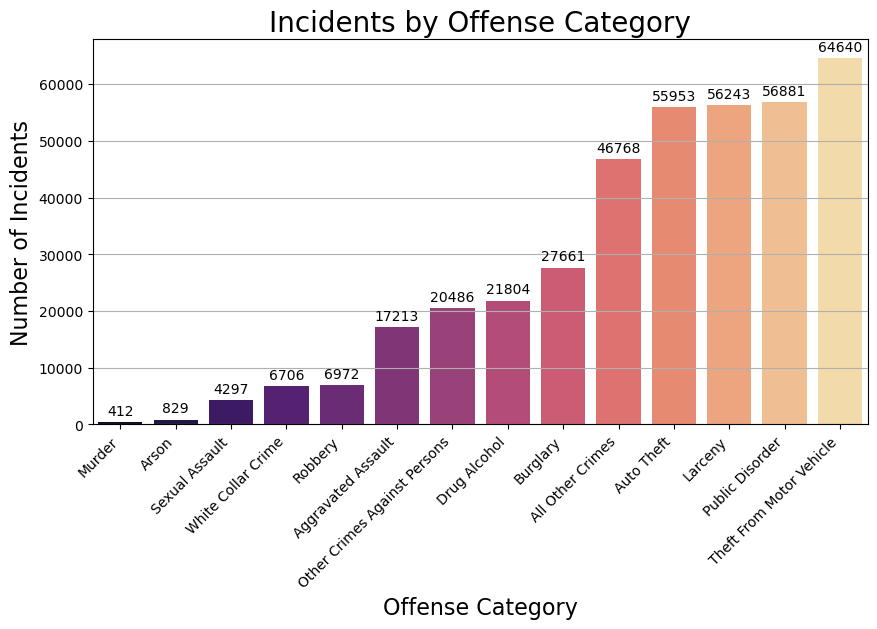

In [28]:
# Create bar chart
incidents_offense_ax = sns.barplot(data=grouped, x='offense_category', y='incident_id', palette='magma')

fig = plt.gcf()
fig.set_size_inches(10, 5)

# Add value labels automatically
for container in incidents_offense_ax.containers:
    incidents_offense_ax.bar_label(container, fmt='%.f', padding=3)

# Add title
incidents_offense_ax.set_title('Incidents by Offense Category', fontsize=20)

# Adjust axis labels
incidents_offense_ax.set_xlabel('Offense Category', fontsize=16)
incidents_offense_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust xticks
orig_labels = [label.get_text() for label in plt.xticks()[1]]
incidents_offense_ax.set_xticklabels([(i.replace('-', ' ').title()) for i in orig_labels])
plt.xticks(rotation=45, ha='right')

incidents_offense_ax.grid(visible=True, axis='y')
plt.show()


#### What is the breakdown of incidents by district *and* offense type?

In [21]:
# Calculate number of incidents by district by offense category for grouped bar chart
grouped_by_district = df.groupby(['district_id', 'offense_category'])['incident_id'].count().reset_index()
grouped_by_district = grouped_by_district.sort_values(
    by=['district_id', 'incident_id'],
    ascending=[True, True]
    )
grouped_by_district

,district_id,offense_category,incident_id
7,1,murder,74
2,1,arson,146
11,1,sexual-assault,653
13,1,white-collar-crime,735
10,1,robbery,1116
...,...,...,...
113,unknown,all-other-crimes,5
120,unknown,sexual-assault,7
121,unknown,theft-from-motor-vehicle,9
114,unknown,auto-theft,11


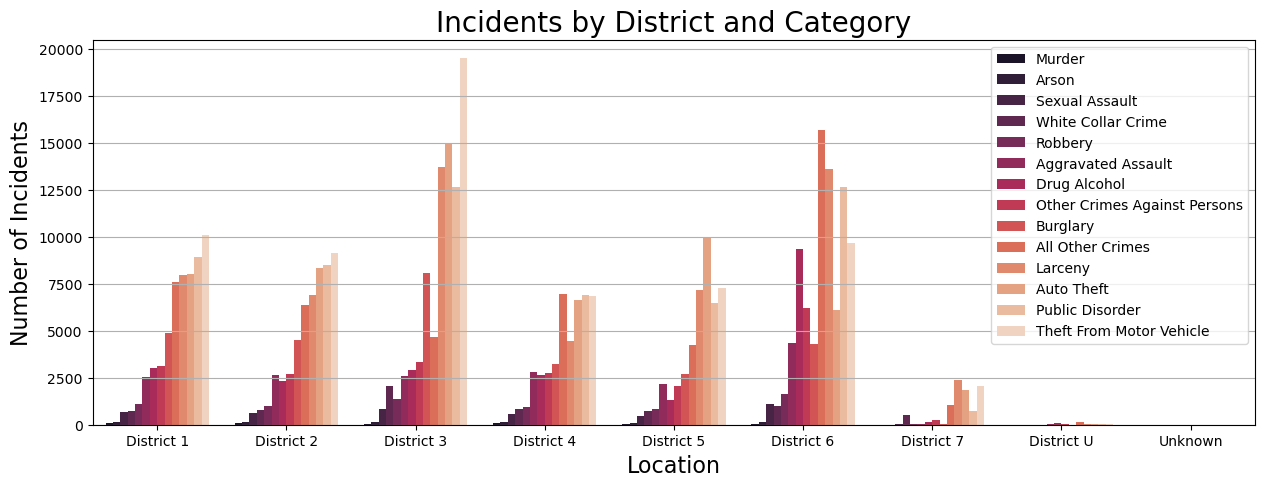

In [29]:
incidents_district_ax = sns.barplot(data=grouped_by_district, x='district_id', y='incident_id', hue='offense_category', palette='rocket')
sns.move_legend(incidents_district_ax, 'upper right')

# Add title
incidents_district_ax.set_title('Incidents by District and Category', fontsize=20)

# Adjust axis labels
incidents_district_ax.set_xlabel('Location', fontsize=16)
incidents_district_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust xtick labels
orig_labels = [i.get_text() for i in plt.xticks()[1]]
incidents_district_ax.set_xticklabels([f"District {i}" if i != 'unknown' else 'Unknown' for i in orig_labels ])

# Adjust legend
plt.legend(fontsize=10)
handles, legend_labels = incidents_district_ax.get_legend_handles_labels()
incidents_district_ax.legend(handles=handles, labels=[i.replace('-', ' ').title() for i in legend_labels])

fig = plt.gcf()
fig.set_size_inches(15, 5)

incidents_district_ax.grid(visible=True, axis='y')
plt.show()

### Incidents Over Time [Line Charts]

In [32]:
df.head(3).T

,0,1,2
incident_id,202268791,2021387586,2020641486
offense_id,202268791299900,2021387586299900,2020641486299900
offense_code,2999,2999,2999
offense_code_extension,0,0,0
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00
last_occurrence_date,NaT,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD


In [33]:
datetime_cols = [
    'first_occurrence_date', 
    'last_occurrence_date',
    'reported_date',
    ]

print(df[datetime_cols].min())
print(df[datetime_cols].max())

first_occurrence_date   2018-01-02 00:00:00
last_occurrence_date    2018-01-02 00:10:00
reported_date           2018-01-02 01:41:00
dtype: datetime64[ns]
first_occurrence_date   2023-10-03 20:40:00
last_occurrence_date    2023-10-03 21:10:00
reported_date           2023-10-03 22:12:00
dtype: datetime64[ns]


#### How have incidents changed over time?
- Based on reported date

In [34]:
df['reported_date_year'] = df.first_occurrence_date.dt.year
df.head(3).T

,0,1,2
incident_id,202268791,2021387586,2020641486
offense_id,202268791299900,2021387586299900,2020641486299900
offense_code,2999,2999,2999
offense_code_extension,0,0,0
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00
last_occurrence_date,NaT,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD


In [35]:
year_incidents = df.groupby(['reported_date_year'])['incident_id'].count().reset_index()
year_incidents

,reported_date_year,incident_id
0,2018,57154
1,2019,57640
2,2020,63784
3,2021,72623
4,2022,77098
5,2023,58566


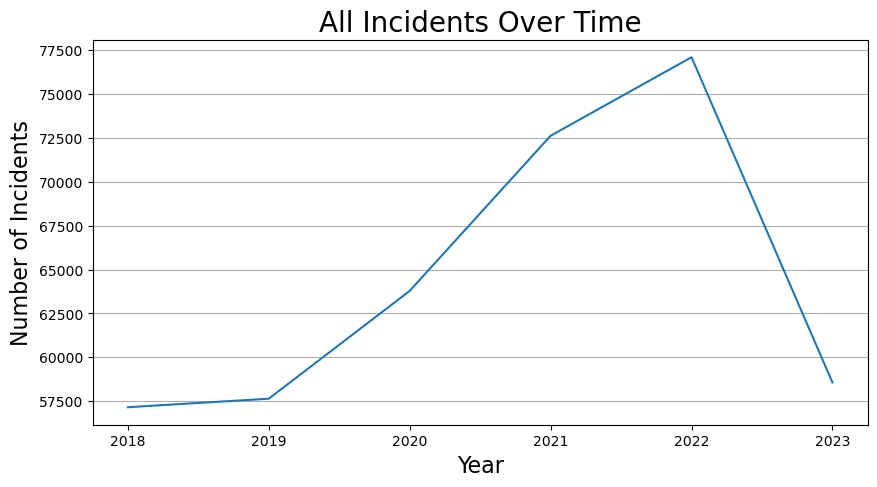

In [36]:
yearly_incidents_ax = sns.lineplot(data=year_incidents, x='reported_date_year', y='incident_id')

# Add title
yearly_incidents_ax.set_title('All Incidents Over Time', fontsize=20)

# Adjust axis labels
yearly_incidents_ax.set_xlabel('Year', fontsize=16)
yearly_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

yearly_incidents_fig = plt.gcf()
yearly_incidents_fig.set_size_inches(10, 5)

yearly_incidents_ax.grid(visible=True, axis='y')
plt.show()

#### How have incidents *by offense type* changed over time?

- This will be a messy multiline plot so first need to create a new feature to bucket offenses as either violent or non-violent

In [37]:
df.offense_category.unique()
violent_crimes = [
    'sexual-assault',
    'other-crimes-against-persons',
    'murder',
    'robbery',
    'aggravated-assault',
    'arson',
    'burglary',
]
non_violent_crimes = [
    'public-disorder',
    'drugs-alchohol',
    'all-other-crimes',
    'white-collar-crime',
    'larceny',
    'theft-from-motor-vehicle',
    'auto-theft'
]
print(len(violent_crimes) + len(non_violent_crimes) == len(df.offense_category.unique()))


df['is_violent_crime'] = df['offense_category'].isin(violent_crimes)
df.head(5).T
df.tail(5).T


True


,386860,386861,386862,386863,386864
incident_id,2023534182,2023534279,2023533509,2023533048,2023532323
offense_id,2023534182240400,2023534279260900,2023533509131506,2023533048131506,2023532323131506
offense_code,2404,2609,1315,1315,1315
offense_code_extension,0,0,6,6,6
offense_type,theft-of-motor-vehicle,fraud-by-use-of-computer,agg-aslt-shoot,agg-aslt-shoot,agg-aslt-shoot
offense_category,auto-theft,white-collar-crime,aggravated-assault,aggravated-assault,aggravated-assault
first_occurrence_date,2023-10-03 11:30:00,2023-09-27 11:00:00,2023-10-03 10:44:00,2023-10-03 05:30:00,2023-10-02 17:47:00
last_occurrence_date,2023-10-03 15:00:00,NaT,NaT,NaT,NaT
reported_date,2023-10-03 17:40:00,2023-10-03 18:34:00,2023-10-03 12:03:00,2023-10-03 09:47:00,2023-10-02 18:16:00
incident_street_address,8501 E ALAMEDA AVE,517 E BAYAUD AVE,N JOLIET ST / E 55TH AVE,585 S ALTON WAY,1198 N SHERIDAN BLVD


In [38]:
yearly_violent_nonviolent = df.groupby(['reported_date_year', 'is_violent_crime'])['incident_id'].count().reset_index()
yearly_violent_nonviolent.is_violent_crime = yearly_violent_nonviolent.is_violent_crime.apply(
    lambda x: 'Violent Crime' if x == True else 'Non-Violent Crime')
yearly_violent_nonviolent

,reported_date_year,is_violent_crime,incident_id
0,2018,Non-Violent Crime,45625
1,2018,Violent Crime,11529
2,2019,Non-Violent Crime,45378
3,2019,Violent Crime,12262
4,2020,Non-Violent Crime,50111
5,2020,Violent Crime,13673
6,2021,Non-Violent Crime,58194
7,2021,Violent Crime,14429
8,2022,Non-Violent Crime,62648
9,2022,Violent Crime,14450


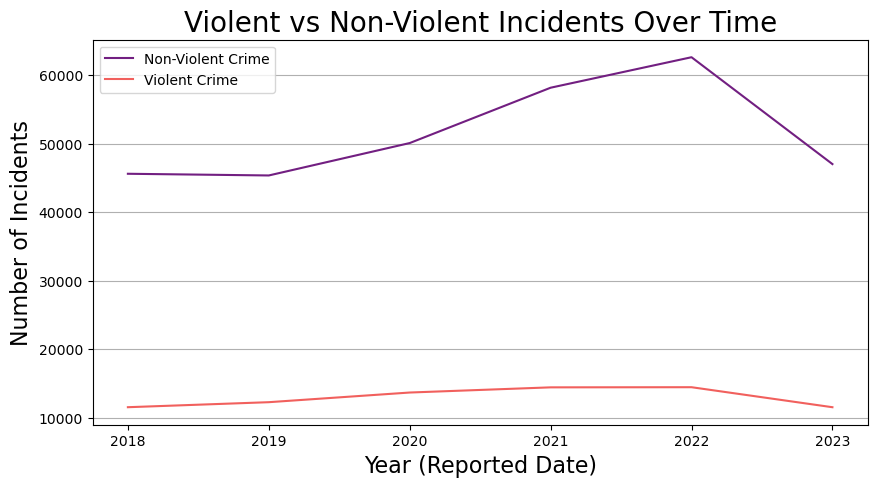

In [39]:
yearly_violent_nonviolent_ax = sns.lineplot(
    data=yearly_violent_nonviolent,
    x='reported_date_year',
    y='incident_id',
    hue='is_violent_crime',
    palette='magma'
    )

# Add title
yearly_violent_nonviolent_ax.set_title('Violent vs Non-Violent Incidents Over Time', fontsize=20)

# Adjust axis labels 
yearly_violent_nonviolent_ax.set_xlabel('Year (Reported Date)', fontsize=16)
yearly_violent_nonviolent_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust legend
sns.move_legend(yearly_violent_nonviolent_ax, 'upper right')
plt.legend(fontsize=10)

fig = plt.gcf()
fig.set_size_inches(10,5)

yearly_violent_nonviolent_ax.grid(visible=True, axis='y')
plt.show()

#### What about crime by district over time?

In [40]:
yearly_district_incidents = df.groupby(['reported_date_year', 'district_id'])['incident_id'].count().reset_index()
yearly_district_incidents.head()

,reported_date_year,district_id,incident_id
0,2018,1,9555
1,2018,2,7781
2,2018,3,11752
3,2018,4,7810
4,2018,5,5822


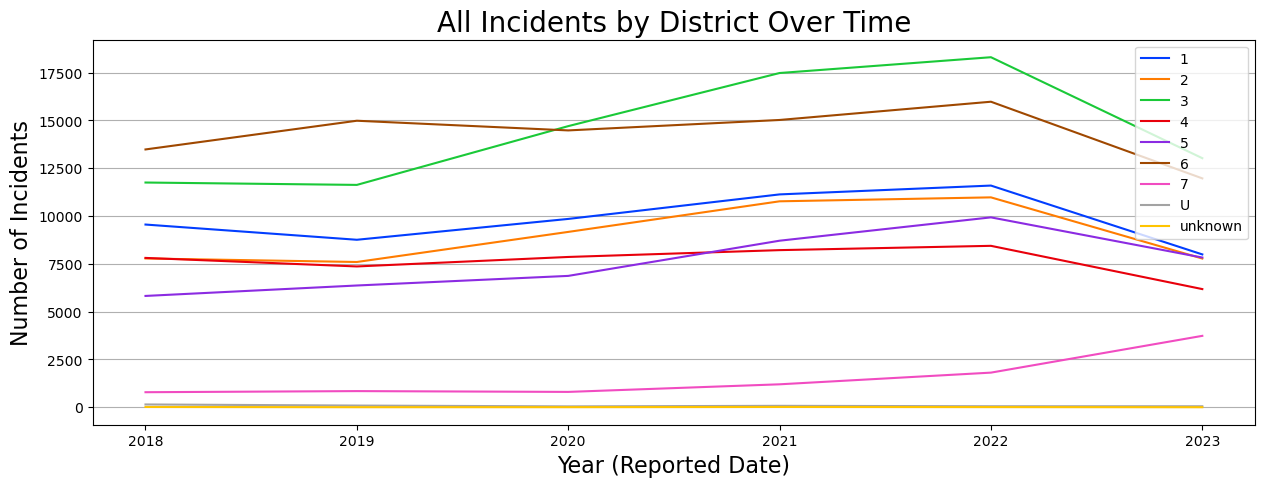

In [42]:
yearly_district_incidents_ax = sns.lineplot(
    data=yearly_district_incidents,
    x='reported_date_year',
    y='incident_id',
    hue='district_id',
    palette='bright'
    )

# Add title
yearly_district_incidents_ax.set_title('All Incidents by District Over Time', fontsize=20)

# Adjust axis labels
yearly_district_incidents_ax.set_xlabel('Year (Reported Date)', fontsize=16)
yearly_district_incidents_ax.set_ylabel('Number of Incidents', fontsize=16)

# Adjust legend
plt.legend(fontsize=10)


fig = plt.gcf()
fig.set_size_inches(15,5)
sns.move_legend(yearly_district_incidents_ax, 'upper right')

yearly_district_incidents_ax.grid(visible=True, axis='y')
plt.show()

### Distribution [Histograms]

Ideas for data to visualize for distribution:
- incidents bucketed by hour of day
- incidents bucketed by day of month
- incidents bucked by month of year
- distribution of victim count


In [43]:
pd.concat([
    df.head(3).T,
    df.tail(3).T
], axis=1)

,0,1,2,386862,386863,386864
incident_id,202268791,2021387586,2020641486,2023533509,2023533048,2023532323
offense_id,202268791299900,2021387586299900,2020641486299900,2023533509131506,2023533048131506,2023532323131506
offense_code,2999,2999,2999,1315,1315,1315
offense_code_extension,0,0,0,6,6,6
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other,agg-aslt-shoot,agg-aslt-shoot,agg-aslt-shoot
offense_category,public-disorder,public-disorder,public-disorder,aggravated-assault,aggravated-assault,aggravated-assault
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00,2023-10-03 10:44:00,2023-10-03 05:30:00,2023-10-02 17:47:00
last_occurrence_date,NaT,NaT,NaT,NaT,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00,2023-10-03 12:03:00,2023-10-03 09:47:00,2023-10-02 18:16:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD,N JOLIET ST / E 55TH AVE,585 S ALTON WAY,1198 N SHERIDAN BLVD


#### Distribution of all incidents by hour of day

In [44]:
df['first_occur_date_hour'] = df.first_occurrence_date.dt.hour
df['first_occur_date_dow'] = df.first_occurrence_date.dt.day_of_week
df['first_occur_date_date'] = df.first_occurrence_date.dt.day
df.head(3).T

,0,1,2
incident_id,202268791,2021387586,2020641486
offense_id,202268791299900,2021387586299900,2020641486299900
offense_code,2999,2999,2999
offense_code_extension,0,0,0
offense_type,criminal-mischief-other,criminal-mischief-other,criminal-mischief-other
offense_category,public-disorder,public-disorder,public-disorder
first_occurrence_date,2022-02-10 02:50:00,2021-07-07 21:02:00,2020-10-29 01:30:00
last_occurrence_date,NaT,NaT,NaT
reported_date,2022-02-10 03:16:00,2021-07-08 00:55:00,2020-10-29 04:31:00
incident_street_address,1107 N SANTA FE DR,815 16TH ST,4745 N FEDERAL BLVD


In [45]:
subset_cols = ['victim_count', 'first_occur_date_hour', 'first_occur_date_dow', 'first_occur_date_date']
subset = df[subset_cols]
subset.corr()

,victim_count,first_occur_date_hour,first_occur_date_dow,first_occur_date_date
victim_count,1.000000,0.002375,0.013412,-0.002740
first_occur_date_hour,0.002375,1.000000,-0.007848,0.013199
first_occur_date_dow,0.013412,-0.007848,1.000000,-0.000503
first_occur_date_date,-0.002740,0.013199,-0.000503,1.000000


<Axes: xlabel='first_occur_date_hour', ylabel='Count'>

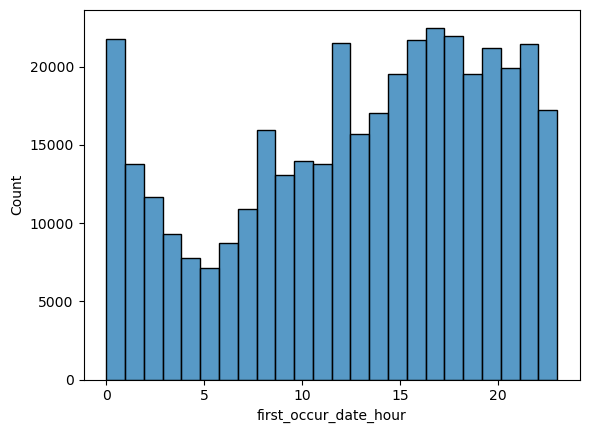

In [46]:
sns.histplot(data=df, x='first_occur_date_hour', bins=24, stat='count')

In [47]:
neighborhoods = df.neighborhood_name.unique().tolist()
neighborhoods.sort()
neighborhoods

['athmar-park',
 'auraria',
 'baker',
 'barnum',
 'barnum-west',
 'bear-valley',
 'belcaro',
 'berkeley',
 'capitol-hill',
 'cbd',
 'central-park',
 'chaffee-park',
 'cheesman-park',
 'cherry-creek',
 'city-park',
 'city-park-west',
 'civic-center',
 'clayton',
 'cole',
 'college-view-south-platte',
 'congress-park',
 'cory-merrill',
 'country-club',
 'dia',
 'east-colfax',
 'elyria-swansea',
 'five-points',
 'fort-logan',
 'gateway-green-valley-ranch',
 'globeville',
 'goldsmith',
 'hale',
 'hampden',
 'hampden-south',
 'harvey-park',
 'harvey-park-south',
 'highland',
 'hilltop',
 'indian-creek',
 'jefferson-park',
 'kennedy',
 'lincoln-park',
 'lowry-field',
 'mar-lee',
 'marston',
 'montbello',
 'montclair',
 'north-capitol-hill',
 'north-park-hill',
 'northeast-park-hill',
 'overland',
 'platt-park',
 'regis',
 'rosedale',
 'ruby-hill',
 'skyland',
 'sloan-lake',
 'south-park-hill',
 'southmoor-park',
 'speer',
 'sun-valley',
 'sunnyside',
 'union-station',
 'university',
 'univer

### Geo Plots

In [76]:
import statistics

all_lats = df.query('incident_latitude != ""').incident_latitude.tolist()
all_longs = df.query('incident_longitude != ""').incident_longitude.tolist()

mean_lat = statistics.mean(all_lats)
mean_long = statistics.mean(all_longs)

print("mean lat", mean_lat, "mean long", mean_long)

mean lat 39.73060696073657 mean long -104.94289635881712


In [49]:
# https://opendata-geospatialdenver.hub.arcgis.com/datasets/3e57d472afbf4326867c1a4c9d4e7c91_13/explore?location=39.700312%2C-104.904305%2C11
with open("source_data\denver_nbhds.geojson", "r") as f:
    geojson_data = json.load(f)

In [50]:
geojson_data.keys()

dict_keys(['type', 'crs', 'features'])

In [77]:
# nbd_incidents = df.groupby(['neighborhood_name'])['incident_id'].count().reset_index()
# nbd_incidents.neighborhood_name = nbd_incidents.neighborhood_name.apply(lambda x: x.replace('-', ' ').title())
# nbd_incidents.rename(mapper={
#     'neighborhood_name': 'nbd_name',
#     'incident_id': 'num_incidents'
# }, inplace=True, axis=1)
# nbd_incidents.nbd_name.unique()

In [81]:
nbd_rename_map = {
    'Cbd': 'CBD',
    'Cory Merrill': 'Cory - Merrill',
    'Dia': 'DIA',
    'Gateway Green Valley Ranch': 'Gateway - Green Valley Ranch'
}

In [82]:
cleaned_nbd_name_df = df.copy()
cleaned_nbd_name_df.neighborhood_name = cleaned_nbd_name_df.neighborhood_name.apply(lambda x: x.replace('-', ' ').title())

cleaned_nbd_name_df.neighborhood_name = cleaned_nbd_name_df.neighborhood_name.replace(nbd_rename_map)
cleaned_nbd_name_df.neighborhood_name.unique()

array(['Lincoln Park', 'CBD', 'Berkeley', 'Barnum', 'Montbello',
       'Highland', 'Capitol Hill', 'Clayton', 'Congress Park', 'Whittier',
       'Barnum West', 'Gateway - Green Valley Ranch', 'Central Park',
       'Platt Park', 'North Capitol Hill', 'Athmar Park', 'Union Station',
       'Washington Virginia Vale', 'Northeast Park Hill', 'West Colfax',
       'Five Points', 'Westwood', 'Civic Center', 'Sunnyside',
       'Cheesman Park', 'City Park West', 'Baker', 'East Colfax',
       'Skyland', 'University Hills', 'Overland', 'West Highland',
       'Valverde', 'College View South Platte', 'Jefferson Park',
       'Cherry Creek', 'Hale', 'Harvey Park South', 'Hampden', 'Rosedale',
       'Globeville', 'Goldsmith', 'Lowry Field', 'Speer',
       'Elyria Swansea', 'Chaffee Park', 'Villa Park', 'Sun Valley',
       'DIA', 'Cory - Merrill', 'Cole', 'Harvey Park',
       'Washington Park West', 'Washington Park', 'Mar Lee', 'University',
       'Bear Valley', 'Hampden South', 'Belcaro'

In [83]:
cleaned_nbd_violent_df = cleaned_nbd_name_df.query('is_violent_crime == True').groupby(['neighborhood_name'])['incident_id'].count().reset_index()
cleaned_nbd_violent_df.head()

,neighborhood_name,incident_id
0,Athmar Park,868
1,Auraria,437
2,Baker,1251
3,Barnum,653
4,Barnum West,353


In [ ]:
nbd_violent_crime_fig = px.choropleth_map(
    cleaned_nbd_violent_df,
    geojson=geojson_data,
    locations='neighborhood_name',
    featureidkey='properties.NBHD_NAME',
    color='incident_id',
    color_continuous_scale='reds',
    opacity=0.5,
    map_style='carto-positron',
    center={'lat': mean_lat, 'lon': mean_long},
    zoom=9,
    width=1000,
    height=700
    )

nbd_violent_crime_fig.show()

In [85]:
cleaned_nbd_nonviolent_df = cleaned_nbd_name_df.query('is_violent_crime == False').groupby(['neighborhood_name'])['incident_id'].count().reset_index()
cleaned_nbd_nonviolent_df

,neighborhood_name,incident_id
0,Athmar Park,3031
1,Auraria,2774
2,Baker,5601
3,Barnum,2294
4,Barnum West,1549
...,...,...
74,West Colfax,6547
75,West Highland,2945
76,Westwood,5397
77,Whittier,1824


In [87]:
nbd_nonviolnent_crime_fig = px.choropleth_map(
    cleaned_nbd_nonviolent_df,
    geojson=geojson_data,
    locations='neighborhood_name',
    featureidkey='properties.NBHD_NAME',
    color='incident_id',
    color_continuous_scale='reds',
    opacity=0.5,
    map_style='carto-positron',
    center={'lat': mean_lat, 'lon': mean_long},
    zoom=9,
    width=1000,
    height=700
    )

nbd_nonviolnent_crime_fig.show()